# Lecture 09 — Inferencia con Modelos Preentrenados: YOLO

**Introduccion a la Inteligencia Artificial — EAFIT 2026-01**

---

En esta clase vamos a trabajar con un modelo de IA **preentrenado** para realizar inferencia sobre imagenes. El modelo que usaremos es **YOLO (You Only Look Once)**, uno de los detectores de objetos mas populares y eficientes del mundo.

### ¿Que aprenderemos hoy?

| Nivel | Descripcion | Herramientas |
|-------|-------------|--------------|
| **Nivel 1** | Inferencia directa con YOLO en el notebook | Python, Ultralytics |
| **Nivel 2** | YOLO como API REST local | Docker, FastAPI |

> En esta sesion cubrimos el **Nivel 1** completo.

### Concepto clave: ¿Que es inferencia?

**Inferencia** es el proceso de usar un modelo ya entrenado para hacer predicciones sobre datos nuevos.  
No entrenamos nada — simplemente usamos el conocimiento que el modelo ya adquirio.

## 1. ¿Que es YOLO?

YOLO es una **red neuronal convolucional** disenada para detectar objetos en imagenes en tiempo real.

### ¿Como funciona?

A diferencia de enfoques anteriores que analizaban una imagen en multiples pasadas, YOLO divide la imagen en una cuadricula y **en una sola pasada** predice simultaneamente:

```
Imagen de entrada
      |
      v
┌─────────────────────────────────────────┐
│         Red Neuronal YOLO               │
│   (procesamiento en una sola pasada)    │
└─────────────────────────────────────────┘
      |
      v
Para cada region de la imagen:
  - ¿Que objeto hay?     → clase (persona, carro, perro...)
  - ¿Donde esta?         → bounding box (x, y, ancho, alto)
  - ¿Que tan seguro?     → confidence score (0.0 a 1.0)
```

### Modelos disponibles (familia YOLO26 — enero 2026)

| Modelo | Parametros | mAP COCO | Velocidad | Uso recomendado |
|--------|-----------|----------|-----------|-----------------|
| `yolo26n.pt` | 2.4 M | 40.9 | Muy rapido | Prototipado, edge devices |
| `yolo26s.pt` | 9.5 M | 48.6 | Rapido | Aplicaciones moviles |
| `yolo26m.pt` | 20.4 M | 53.1 | Moderado | Uso general |
| `yolo26l.pt` | 24.8 M | 55.0 | Lento | Produccion |
| `yolo26x.pt` | 55.7 M | 57.5 | Muy lento | Investigacion |

> En esta clase usaremos **`yolo26n.pt`** (nano) — 2.4 millones de parametros, suficiente para aprender los conceptos.

### Novedad de YOLO26: sin NMS

Versiones anteriores necesitaban un paso post-procesamiento llamado **NMS (Non-Maximum Suppression)** para eliminar detecciones duplicadas. YOLO26 incorpora ese filtrado **dentro de la red neuronal**, simplificando el despliegue.

### Dataset de entrenamiento: COCO

YOLO fue preentrenado con el dataset **COCO (Common Objects in Context)** que contiene:
- ~330,000 imagenes
- 80 clases de objetos cotidianos (personas, vehiculos, animales, muebles, etc.)

## 2. Instalacion

Solo necesitamos una libreria: **`ultralytics`**, que incluye YOLO y todas sus dependencias.

In [1]:
%pip install ultralytics --quiet

Note: you may need to restart the kernel to use updated packages.


## 3. Cargando el modelo

Al ejecutar `YOLO("yolo26n.pt")` por primera vez, el modelo se **descarga automaticamente** desde los servidores de Ultralytics y se guarda localmente para usos futuros.

> `yolo26n.pt` tiene **2.4 millones de parametros** — cada uno es un numero que la red aprendio durante el entrenamiento con millones de imagenes.

In [1]:
from ultralytics import YOLO

# Cargar modelo preentrenado (se descarga automaticamente si no existe)
model = YOLO("yolo26n.pt")

print(f"Modelo cargado: {type(model)}")
print(f"Numero de clases que puede detectar: {len(model.names)}")
print(f"\nPrimeras 5 clases: {list(model.names.values())[:5]}")

Modelo cargado: <class 'ultralytics.models.yolo.model.YOLO'>
Numero de clases que puede detectar: 80

Primeras 5 clases: ['person', 'bicycle', 'car', 'motorcycle', 'airplane']


In [2]:
# Ver todas las clases que YOLO puede detectar
print("Todas las clases del dataset COCO:\n")
for id, nombre in model.names.items():
    print(f"  {id:3d}: {nombre}")

Todas las clases del dataset COCO:

    0: person
    1: bicycle
    2: car
    3: motorcycle
    4: airplane
    5: bus
    6: train
    7: truck
    8: boat
    9: traffic light
   10: fire hydrant
   11: stop sign
   12: parking meter
   13: bench
   14: bird
   15: cat
   16: dog
   17: horse
   18: sheep
   19: cow
   20: elephant
   21: bear
   22: zebra
   23: giraffe
   24: backpack
   25: umbrella
   26: handbag
   27: tie
   28: suitcase
   29: frisbee
   30: skis
   31: snowboard
   32: sports ball
   33: kite
   34: baseball bat
   35: baseball glove
   36: skateboard
   37: surfboard
   38: tennis racket
   39: bottle
   40: wine glass
   41: cup
   42: fork
   43: knife
   44: spoon
   45: bowl
   46: banana
   47: apple
   48: sandwich
   49: orange
   50: broccoli
   51: carrot
   52: hot dog
   53: pizza
   54: donut
   55: cake
   56: chair
   57: couch
   58: potted plant
   59: bed
   60: dining table
   61: toilet
   62: tv
   63: laptop
   64: mouse
   65: remote


## 4. Inferencia sobre una imagen

Vamos a descargar una imagen de prueba y ejecutar YOLO sobre ella.

YOLO acepta como entrada:
- Una ruta a un archivo de imagen (`"foto.jpg"`)
- Una URL directa a una imagen
- Un array NumPy
- Un objeto PIL Image

Imagen ya existe: images/bus.jpg


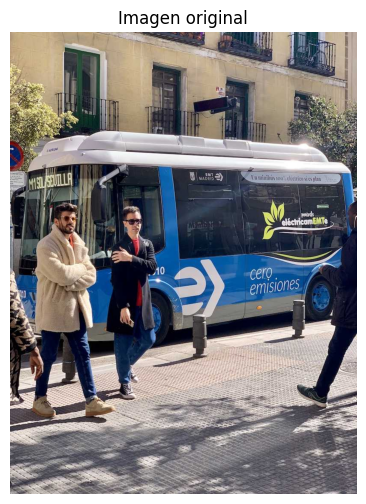

Tamano de la imagen: 810x1080 pixeles


In [6]:
import urllib.request #Libreria para descargar archivos desde internet
from pathlib import Path #Libreria para manejar rutas de archivos de manera sencilla y multiplataforma

# Descargar imagen de prueba (imagen de ejemplo de Ultralytics)
url = "https://ultralytics.com/images/bus.jpg"
imagen_path = "images/bus.jpg"

if not Path(imagen_path).exists():
    urllib.request.urlretrieve(url, imagen_path) #Descargar la imagen desde la URL y guardarla localmente
    print(f"Imagen descargada: {imagen_path}")
else:
    print(f"Imagen ya existe: {imagen_path}")

# Mostrar imagen original
from PIL import Image #Libreria para abrir y manipular imagenes (Pillow)
import matplotlib.pyplot as plt

img = Image.open(imagen_path)
plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.title("Imagen original")
plt.axis("off")
plt.show()
print(f"Tamano de la imagen: {img.size[0]}x{img.size[1]} pixeles")

In [7]:
# Ejecutar inferencia
resultados = model(imagen_path)

print(f"Tipo del resultado: {type(resultados)}")
print(f"Numero de imagenes procesadas: {len(resultados)}")
#print(f"Resultados: {resultados[0]}")


image 1/1 /teamspace/studios/this_studio/AIClass/InteligenciaArtificialIS/Lecture09/notebooks/yolo/images/bus.jpg: 640x480 4 persons, 1 bus, 107.7ms
Speed: 3.4ms preprocess, 107.7ms inference, 19.6ms postprocess per image at shape (1, 3, 640, 480)
Tipo del resultado: <class 'list'>
Numero de imagenes procesadas: 1


## 5. Explorando el objeto de resultados

YOLO retorna una lista de objetos `Results`. Cada uno contiene toda la informacion de las detecciones para esa imagen.

In [8]:
# Acceder al resultado de la primera (y unica) imagen
r = resultados[0] # r es un objeto de tipo 'ultralytics.yolo.engine.results.Results' que contiene toda la informacion de la inferencia

print("=== Informacion general ===")
print(f"Imagen original: {r.path}")
print(f"Tamano procesado: {r.orig_shape}")
print(f"Objetos detectados: {len(r.boxes)}")


print("\n=== Detecciones ===")
for i, box in enumerate(r.boxes):
    clase_id  = int(box.cls[0])
    clase_nom = model.names[clase_id]
    confianza = float(box.conf[0])
    x1, y1, x2, y2 = box.xyxy[0].tolist()
    
    print(f"  [{i+1}] {clase_nom:15s} | confianza: {confianza:.2f} | bbox: ({x1:.0f},{y1:.0f}) → ({x2:.0f},{y2:.0f})")

=== Informacion general ===
Imagen original: /teamspace/studios/this_studio/AIClass/InteligenciaArtificialIS/Lecture09/notebooks/yolo/images/bus.jpg
Tamano procesado: (1080, 810)
Objetos detectados: 5

=== Detecciones ===
  [1] bus             | confianza: 0.92 | bbox: (0,229) → (806,757)
  [2] person          | confianza: 0.91 | bbox: (222,405) → (345,862)
  [3] person          | confianza: 0.91 | bbox: (48,399) → (239,903)
  [4] person          | confianza: 0.87 | bbox: (671,392) → (810,879)
  [5] person          | confianza: 0.55 | bbox: (0,557) → (60,870)


## 6. Visualizando las detecciones

YOLO puede generar automaticamente la imagen anotada con los bounding boxes y etiquetas.

### Conversion BGR a RGB

`r.plot()` retorna la imagen usando **OpenCV** internamente, que historicamente guarda los canales de color en orden **BGR** (Azul, Verde, Rojo). Matplotlib en cambio espera orden **RGB** (Rojo, Verde, Azul).

```
OpenCV / YOLO         Matplotlib
canal 0 = Azul   →   canal 0 = Rojo
canal 1 = Verde  →   canal 1 = Verde
canal 2 = Rojo   →   canal 2 = Azul
```

Si mostramos la imagen sin convertir, los colores quedan **invertidos** (lo rojo aparece azul y viceversa).

La conversion se hace con slicing de NumPy:

```python
imagen_anotada_rgb = imagen_anotada[:, :, ::-1]
#                                   │    │   └── invierte el orden de los 3 canales
#                                   │    └────── todos los pixeles del ancho
#                                   └──────────── todos los pixeles del alto
```

El `::-1` recorre el eje de canales al reves: `[0

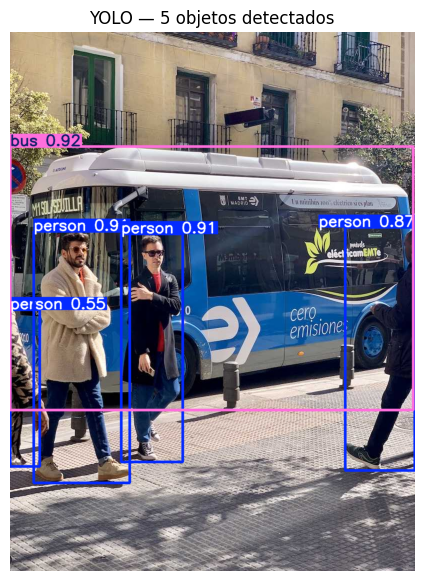

In [9]:
import numpy as np

# r.plot() retorna la imagen anotada como array NumPy (BGR → convertir a RGB para matplotlib)
imagen_anotada = r.plot()
imagen_anotada_rgb = imagen_anotada[:, :, ::-1]  # BGR a RGB

plt.figure(figsize=(12, 7))
plt.imshow(imagen_anotada_rgb)
plt.title(f"YOLO — {len(r.boxes)} objetos detectados")
plt.axis("off")
plt.show()

## 7. Ajustando el umbral de confianza

El parametro `conf` controla que tan "seguro" debe estar YOLO para reportar una deteccion.

- `conf=0.25` → reporta detecciones con 25%+ de confianza (mas detecciones, mas ruido)
- `conf=0.75` → solo detecciones muy seguras (menos detecciones, mas precision)

Experimenta con diferentes valores para ver como afecta los resultados:

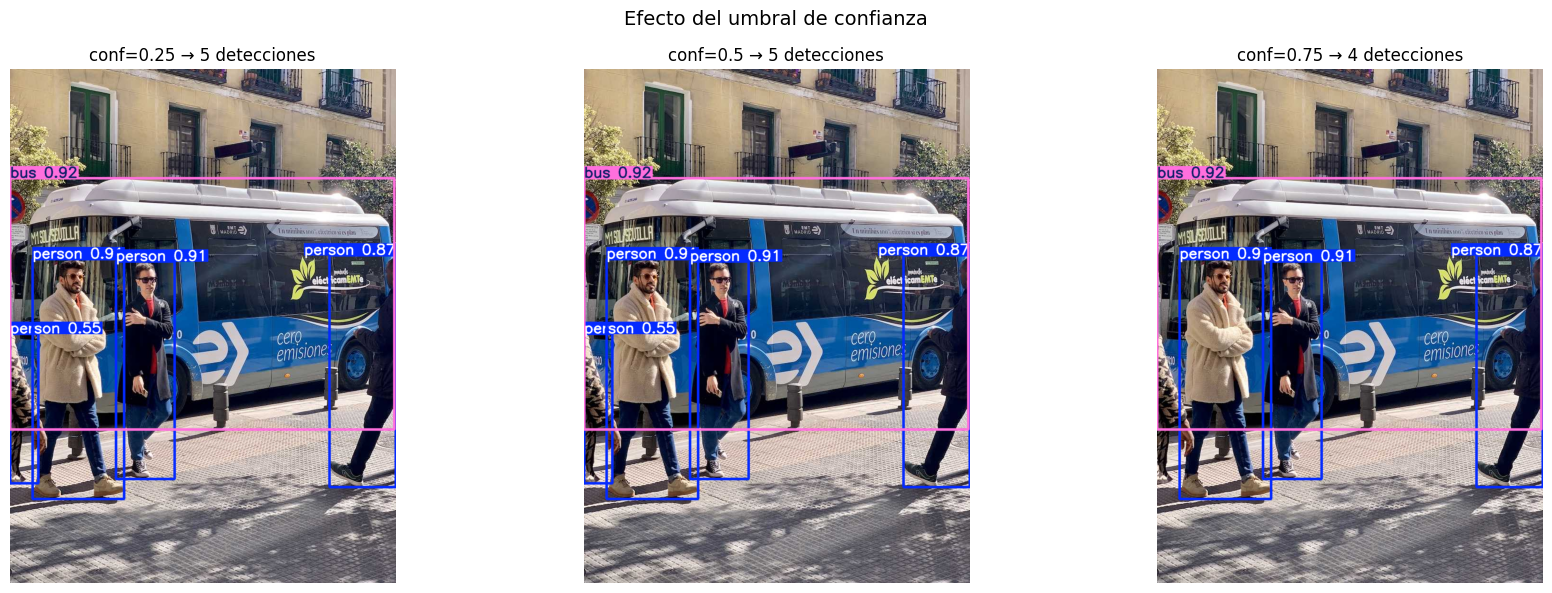

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6)) #Crear una figura con 3 subplots (1 fila, 3 columnas)
umbrales = [0.25, 0.50, 0.75]

for ax, umbral in zip(axes, umbrales): #Iterar sobre cada subplot y umbral de confianza
    r = model(imagen_path, conf=umbral, verbose=False)[0] #Ejecutar inferencia con el umbral de confianza especificado y obtener el resultado para la primera imagen
    img_anotada = r.plot()[:, :, ::-1] 
    ax.imshow(img_anotada)
    ax.set_title(f"conf={umbral} → {len(r.boxes)} detecciones")
    ax.axis("off")

plt.suptitle("Efecto del umbral de confianza", fontsize=14)
plt.tight_layout()
plt.show()

## 8. Ejercicio — Prueba con tu propia imagen

Sube cualquier imagen y ejecuta YOLO sobre ella. Puedes usar una foto tuya, de tu escritorio, o descargar cualquier imagen de internet.

In [9]:
## EJERCICIO: cambia este path por el de tu propia imagen
MI_IMAGEN = "xxxxxx.jpg"   # <-- reemplaza con tu archivo, ej: "mi_foto.jpg"

r = model(MI_IMAGEN, conf="???", verbose=False)[0] # Reemplaza "???" por el umbral de confianza que quieras probar, ej: 0.25, 0.50, 0.75
img_anotada = r.plot()[:, :, ::-1]

plt.figure(figsize=(12, 7))
plt.imshow(img_anotada)
plt.title(f"Tu imagen — {len(r.boxes)} objetos detectados")
plt.axis("off")
plt.show()

print("\nDetecciones:")
for box in r.boxes:
    clase = model.names[int(box.cls[0])]
    conf  = float(box.conf[0])
    print(f"  - {clase} ({conf:.0%} de confianza)")

TypeError: 'conf=???' is of invalid type str. Valid 'conf' types are int (i.e. 'conf=0') or float (i.e. 'conf=0.5')